<link href="https://fonts.googleapis.com/css2?family=Oswald:wght@700&display=swap" rel="stylesheet">

<h1 style="
font-family: 'Oswald', sans-serif;
font-weight: 400;
font-style: italic;
font-size: 50px;
letter-spacing: 2px;
color: #E7C173;
text-shadow: 3px 3px 0 #333;
">
MACHINE LEARNING IN INDUSTRY <br> ASSIGNMENT DAY 1 & 2 <br> <br> Phase 1: Preprocessing
</h1>

Environment ready.
/Users/megang/Desktop/ml_industry_course_Milan_Italy/day2/assignment
Train shape: (96112, 54)
Test shape: (23888, 53)

--- TRAIN ---

--- TEST ---
Columns unavailable at prediction time (drop these):
['account_flag', 'fee_adj', 'last_txn_amt', 'late_fees', 'payments_total', 'principal_recv', 'residual_amt', 'review_gap_m', 'score_recent']
app_kind — TRAIN:
 app_kind
0    96112
Name: count, dtype: int64

app_kind — TEST:
 app_kind
0    23830
1       58
Name: count, dtype: int64
Train shape after drop: (96112, 44)
Test shape after drop: (23888, 43)


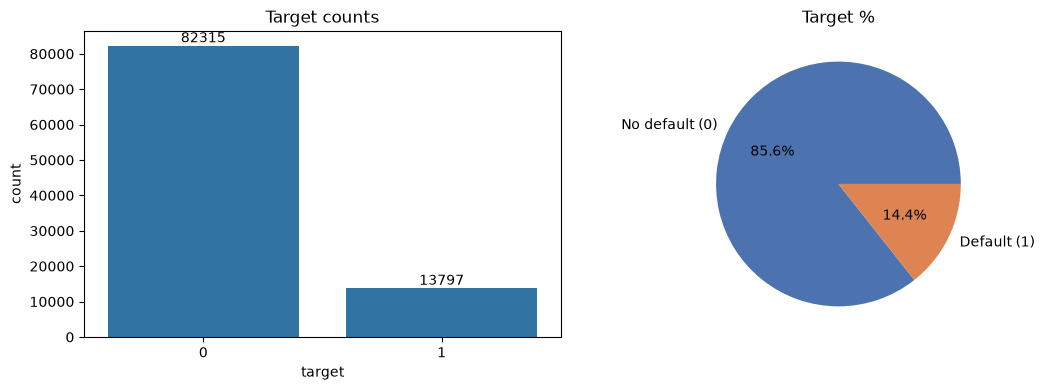

Default rate: 14.36%


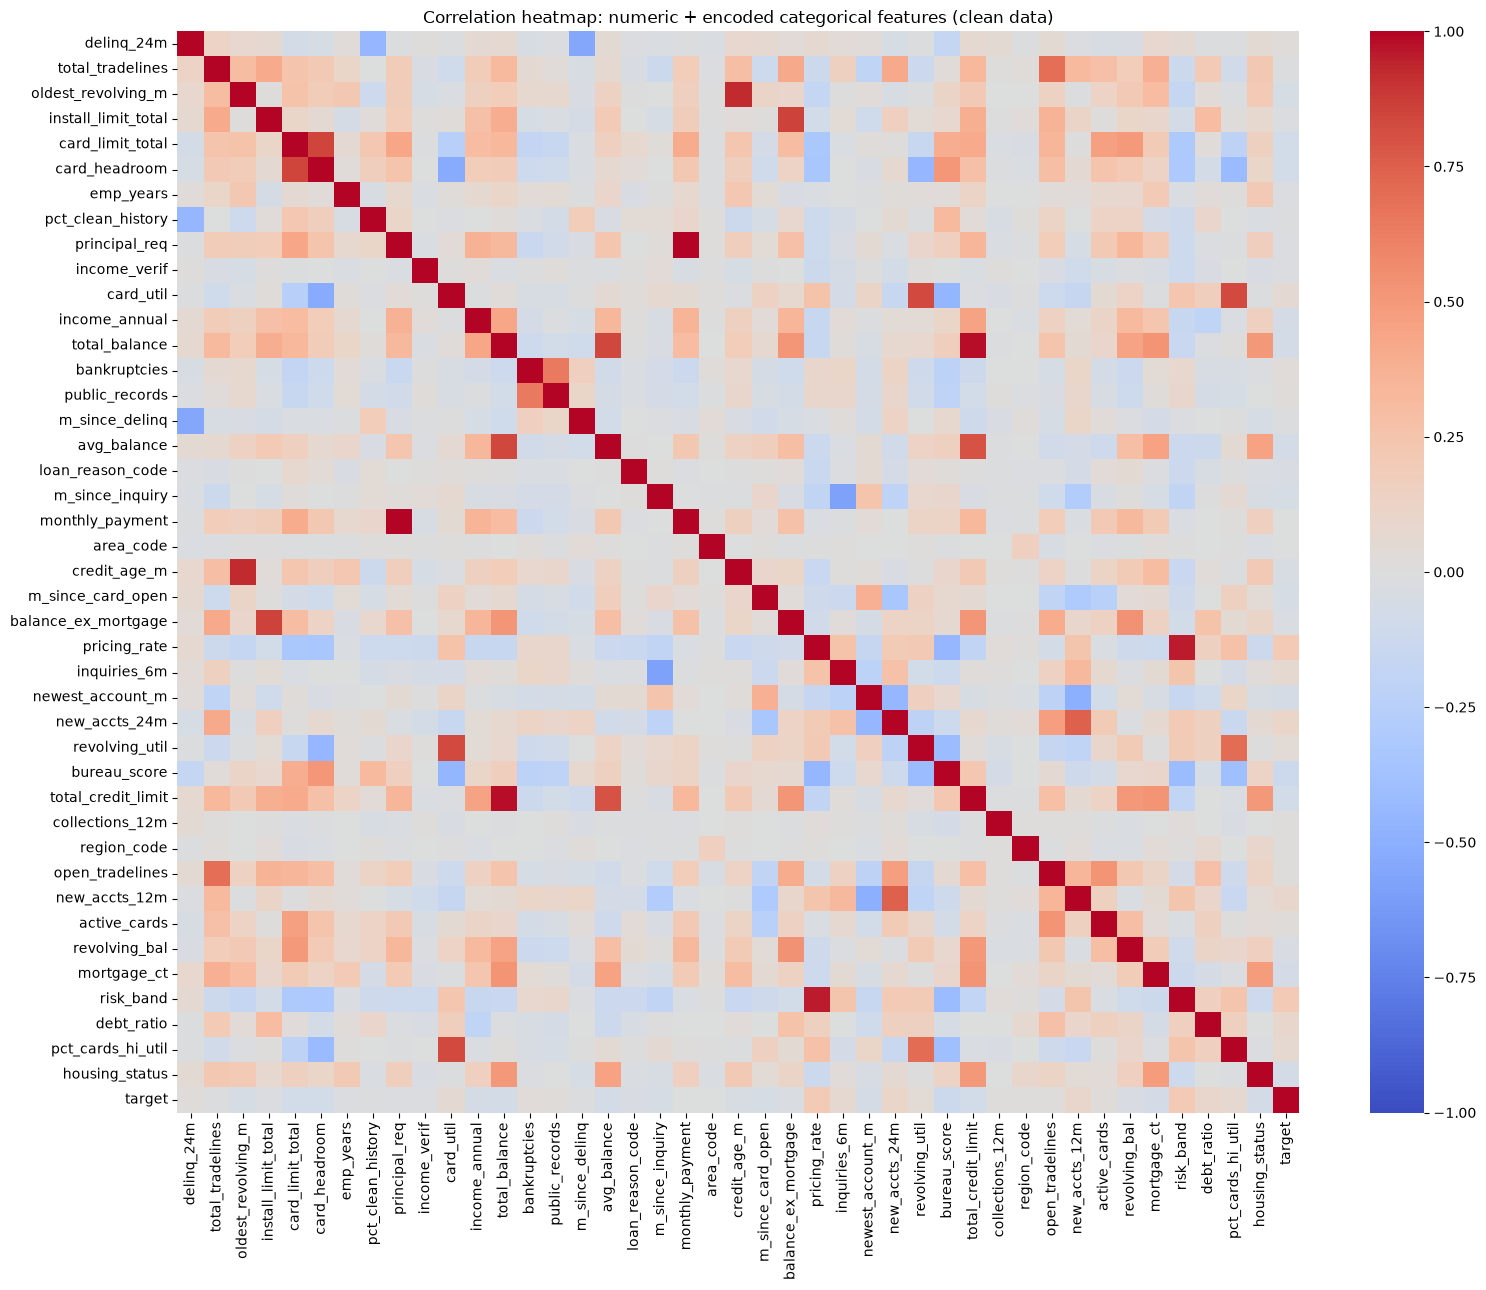

Top 15 features by |correlation| with target (clean data):
pricing_rate          0.204632
risk_band             0.204063
bureau_score         -0.120258
new_accts_24m         0.102410
new_accts_12m         0.092207
debt_ratio            0.087271
total_credit_limit   -0.083917
card_limit_total     -0.083556
card_headroom        -0.081126
avg_balance          -0.077482
total_balance        -0.076866
housing_status       -0.073249
inquiries_6m          0.066945
mortgage_ct          -0.064030
pct_cards_hi_util     0.063454
Name: target, dtype: float64


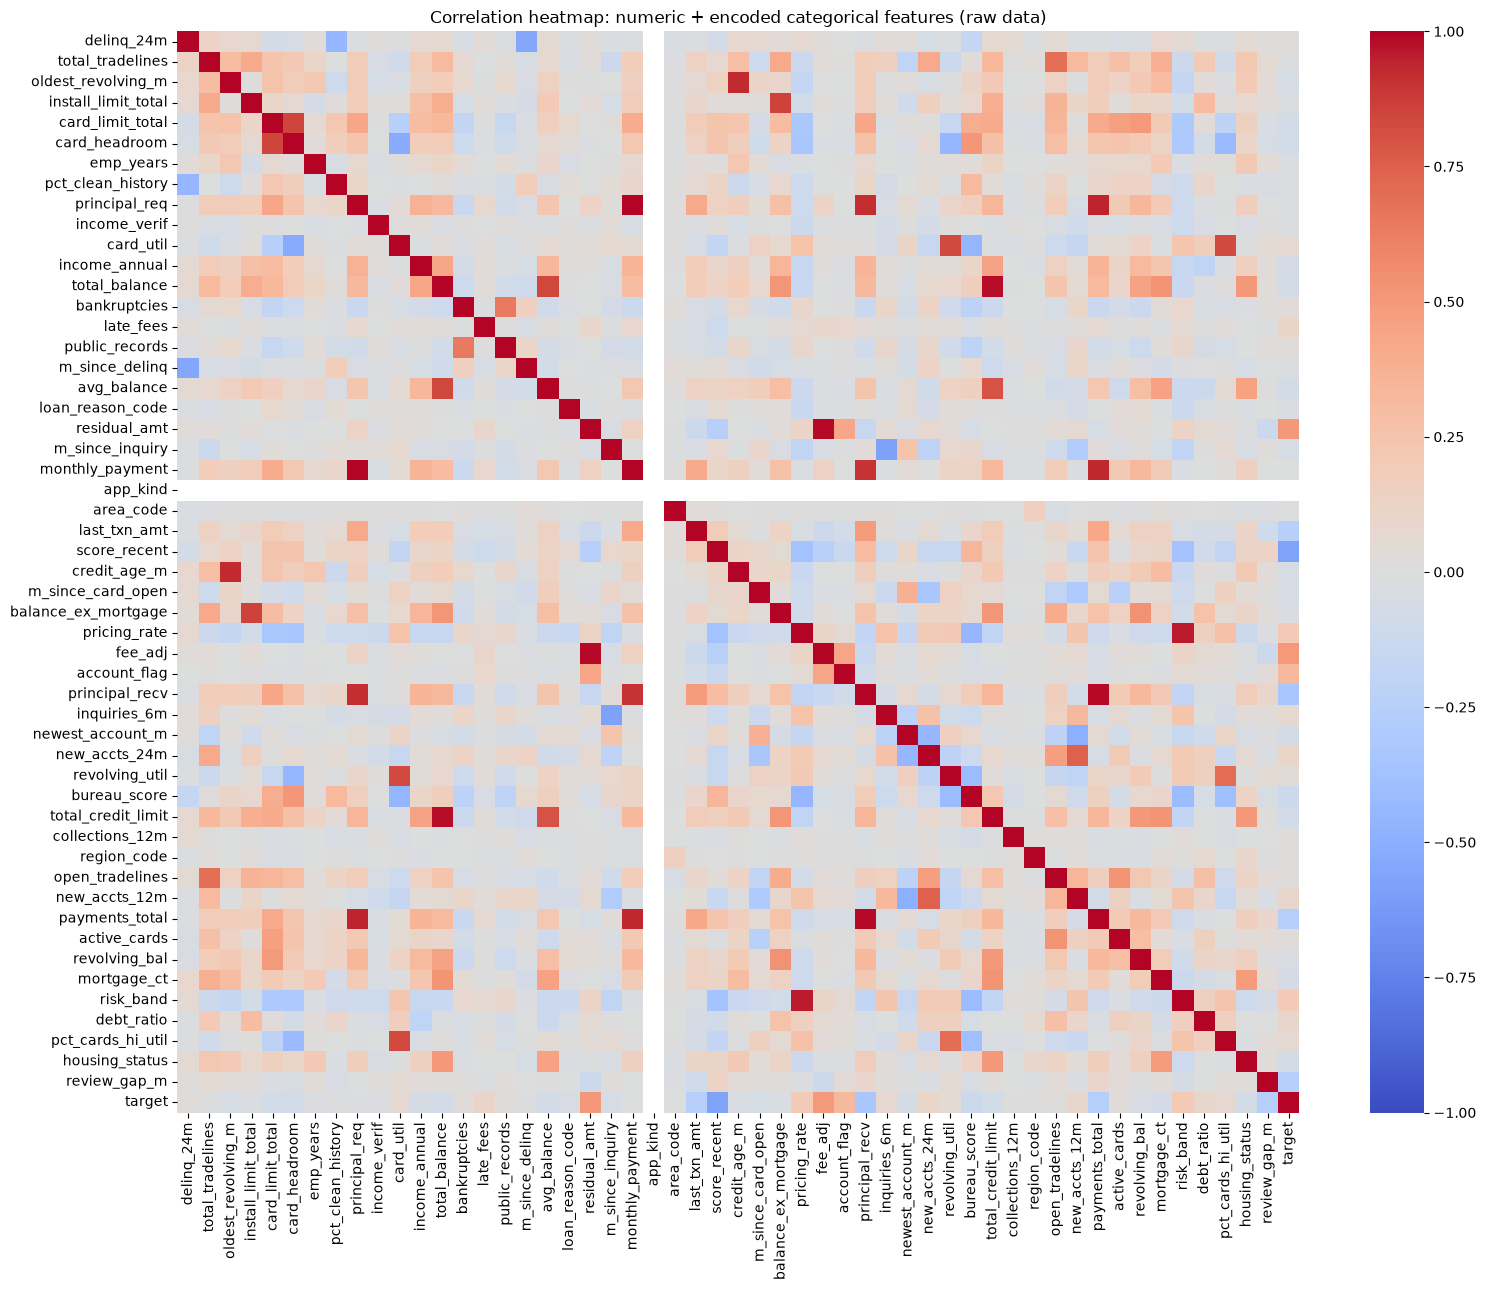

Top 15 features by |correlation| with target (raw data):
score_recent     -0.574896
residual_amt      0.505865
fee_adj           0.495057
principal_recv   -0.330370
account_flag      0.323913
review_gap_m     -0.259923
payments_total   -0.258394
last_txn_amt     -0.251328
pricing_rate      0.204632
risk_band         0.204063
bureau_score     -0.120258
late_fees         0.111342
new_accts_24m     0.102410
new_accts_12m     0.092207
debt_ratio        0.087271
Name: target, dtype: float64
Top 15 features by train/test distribution shift (KS statistic):
                feature   ks_stat        p_value
24         pricing_rate  0.132461  3.382224e-293
9          income_verif  0.063953   1.780539e-68
38            risk_band  0.052993   3.872504e-47
40    pct_cards_hi_util  0.046596   4.086200e-36
28       revolving_util  0.045887   1.970062e-35
5         card_headroom  0.041488   9.530187e-29
10            card_util  0.038506   8.289308e-25
17     loan_reason_code  0.037460   9.169681e-24
4  

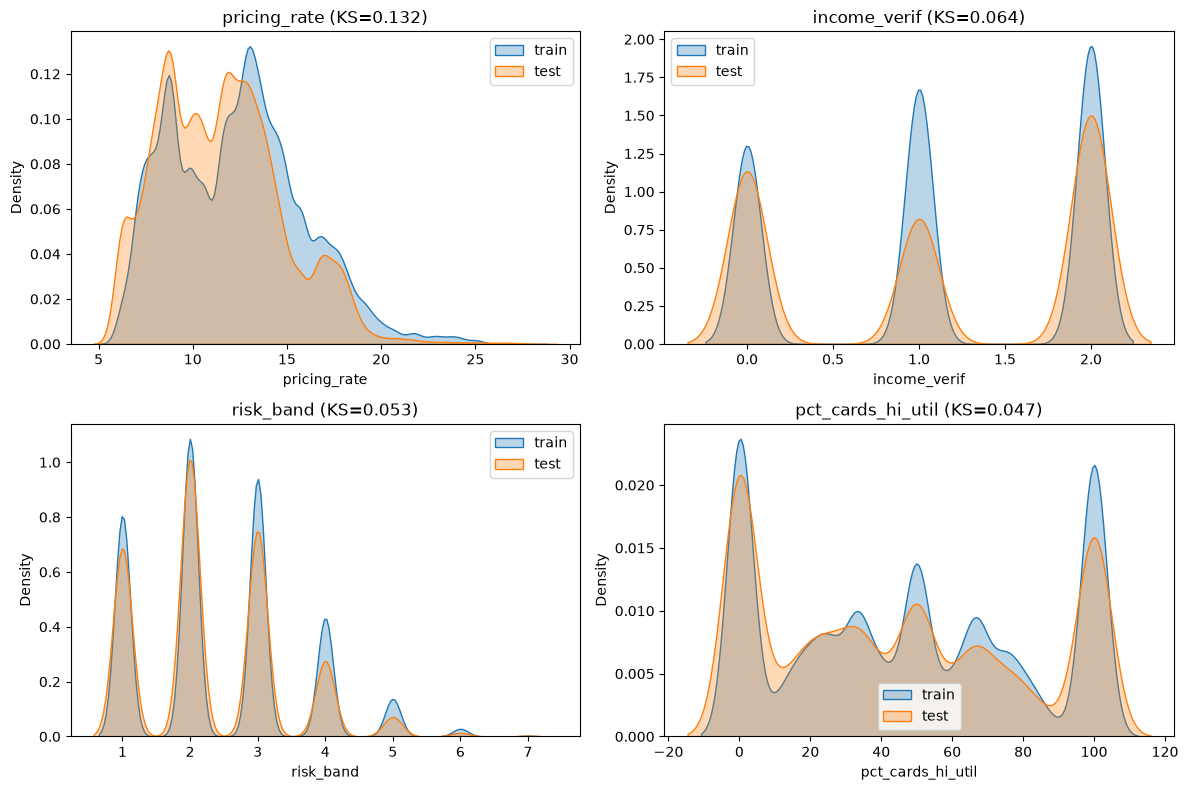

             feature  pct_missing  default_rate_if_missing  \
4        avg_balance     0.002081                 0.500000   
1          emp_years     6.223989                 0.209295   
7     revolving_util     0.056184                 0.203704   
5    m_since_inquiry    10.253662                 0.096093   
6  m_since_card_open     0.940569                 0.155973   
3     m_since_delinq    48.341518                 0.137747   
8  pct_cards_hi_util     1.074788                 0.153921   
2          card_util     1.077909                 0.151544   
0      card_headroom     0.991552                 0.150052   

   default_rate_if_present      diff  
4                 0.143544  0.356456  
1                 0.139188  0.070107  
7                 0.143517  0.060186  
5                 0.148973 -0.052880  
6                 0.143433  0.012540  
3                 0.148983 -0.011236  
8                 0.143439  0.010482  
2                 0.143464  0.008080  
0                 0.143486  

In [1]:
from setup import *

print(os.getcwd()) # checking where this notebook is currently running from

# ============================================================
# 0. Loans dataset & data paths
# ============================================================
TRAIN_PATH = "data/d2assignment_dataset.csv.gz"
TEST_PATH = "data/d2assignment_test.csv.gz"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

target_col = "target"

# ============================================================
# 1. Initial look: dtypes, missing values, unique values
# (reused for the "clean" pass further down)
# ============================================================
def inspect(df, name):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "n_missing": df.isnull().sum(),
        "pct_missing": (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique()
    }).sort_values("pct_missing", ascending=False)
    print(f"\n--- {name} ---")
    return summary


inspect(train, "TRAIN")
inspect(test, "TEST")

# ============================================================
# 1b. Train/Test column availability check (critical!)
# ============================================================
train_missing_pct = train.isnull().mean() * 100
test_missing_pct = test.isnull().mean() * 100

availability = pd.DataFrame({
    "train_pct_missing": train_missing_pct,
    "test_pct_missing": test_missing_pct
}).fillna(0)  # target won't exist in test, that's expected

# Columns 100% missing in test but present in train = leakage risk
leaky_cols = availability[
    (availability["test_pct_missing"] == 100) &
    (availability["train_pct_missing"] < 100)
].index.tolist()
leaky_cols = [c for c in leaky_cols if c != target_col]

print("Columns unavailable at prediction time (drop these):")
print(leaky_cols)

# Check app_kind constant-column issue
print("app_kind — TRAIN:\n", train["app_kind"].value_counts())
print("\napp_kind — TEST:\n", test["app_kind"].value_counts())

# ============================================================
# Final drop list: leakage columns + constant column
# ============================================================
train_raw = train.copy()  # kept original for reference/report
drop_cols = [
    "account_flag", "fee_adj", "last_txn_amt", "late_fees",
    "payments_total", "principal_recv", "residual_amt",
    "review_gap_m", "score_recent", "app_kind"
]

train_clean = train_raw.drop(columns=drop_cols)
test_clean = test.drop(columns=[c for c in drop_cols if c in test.columns])

print("Train shape after drop:", train_clean.shape)
print("Test shape after drop:", test_clean.shape)

# ============================================================
# 2. Target variable distribution (class imbalance)
# ============================================================
counts = train_clean[target_col].value_counts()
rates = train_clean[target_col].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=target_col, data=train_clean, ax=ax[0])
ax[0].set_title("Target counts")
for i, v in enumerate(counts):
    ax[0].text(i, v, str(v), ha="center", va="bottom")

ax[1].pie(rates, labels=["No default (0)", "Default (1)"], autopct="%1.1f%%",
          colors=["#4C72B0", "#DD8452"])
ax[1].set_title("Target %")
plt.tight_layout()
plt.savefig(os.path.join("Figures", "target_distribution.pdf"), dpi=300, bbox_inches="tight")
plt.show()

print(f"Default rate: {rates[1]:.2f}%")

# ============================================================
# 3. Correlation heatmap (numeric + one-hot encoded categoricals)
# Reusable helper — run once on clean data, once on raw data
# ============================================================
def correlation_heatmap(df, target, title_suffix, filename):
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ["row_id", target]]
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    encoded = pd.get_dummies(df[cat_cols], drop_first=True) if cat_cols else pd.DataFrame(index=df.index)
    corr_df = pd.concat([df[num_cols + [target]], encoded], axis=1)
    corr = corr_df.corr()

    plt.figure(figsize=(16, 13))
    sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True)
    plt.title(f"Correlation heatmap: numeric + encoded categorical features ({title_suffix})")
    plt.tight_layout()
    plt.savefig(os.path.join("Figures", filename), dpi=300, bbox_inches="tight")
    plt.show()

    target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)
    print(f"Top 15 features by |correlation| with target ({title_suffix}):")
    print(target_corr.head(15))
    return target_corr


correlation_heatmap(train_clean, target_col, "clean data", "correlation_heatmap_clean_data.pdf")
correlation_heatmap(train, target_col, "raw data", "correlation_heatmap_raw_data.pdf")

# ============================================================
# 4. Train vs test distribution comparison (KS test)
# ============================================================
numeric_cols = [c for c in train_clean.select_dtypes(include=[np.number]).columns
                if c not in ["row_id", target_col]]

drift_results = []
for col in numeric_cols:
    tr = train_clean[col].dropna()
    te = test_clean[col].dropna()
    stat, pval = stats.ks_2samp(tr, te)
    drift_results.append({"feature": col, "ks_stat": stat, "p_value": pval})

drift_df = pd.DataFrame(drift_results).sort_values("ks_stat", ascending=False)
print("Top 15 features by train/test distribution shift (KS statistic):")
print(drift_df.head(15))

# Visualize the worst few offenders
top_drift = drift_df.head(4)["feature"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), top_drift):
    sns.kdeplot(train_clean[col].dropna(), label="train", ax=ax, fill=True, alpha=0.3)
    sns.kdeplot(test_clean[col].dropna(), label="test", ax=ax, fill=True, alpha=0.3)
    ax.set_title(f'{col} (KS={drift_df.set_index("feature").loc[col, "ks_stat"]:.3f})')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join("Figures", "visualize_offenders.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 5. Is missingness informative? Default rate: missing vs present
# ============================================================
missing_cols = [c for c in train_clean.columns[train_clean.isnull().any()] if c != target_col]

rows = []
for col in missing_cols:
    is_missing = train_clean[col].isnull()
    rate_missing = train_clean.loc[is_missing, target_col].mean()
    rate_present = train_clean.loc[~is_missing, target_col].mean()
    rows.append({
        "feature": col,
        "pct_missing": is_missing.mean() * 100,
        "default_rate_if_missing": rate_missing,
        "default_rate_if_present": rate_present,
        "diff": rate_missing - rate_present
    })

missingness_df = pd.DataFrame(rows).sort_values("diff", key=abs, ascending=False)
print(missingness_df)

# ============================================================
# 5a. Create missing-value indicators (0 = present, 1 = missing)
# ============================================================
missing_flag_cols = ["emp_years", "m_since_inquiry", "m_since_delinq", "revolving_util"]

for col in missing_flag_cols:
    train_clean[f"{col}_missing"] = train_clean[col].isna().astype(int)
    test_clean[f"{col}_missing"] = test_clean[col].isna().astype(int)

print("Missing-value indicators created.")

# ============================================================
# 5b. Fill remaining numerical missing values with median
# (train's median is used for both, to avoid leakage from test)
# ============================================================
numeric_cols = [
    col for col in train_clean.select_dtypes(include=["number"]).columns
    if col != target_col and col in test_clean.columns
]

for col in numeric_cols:
    median_value = train_clean[col].median()
    train_clean[col] = train_clean[col].fillna(median_value)
    test_clean[col] = test_clean[col].fillna(median_value)

# ============================================================
# 5c. Treat coded variables as categorical
# ============================================================
cat_col = ["housing_status", "income_verif", "loan_reason_code",
           "risk_band", "region_code", "area_code"]

for col in cat_col:
    train_clean[col] = train_clean[col].astype("category")
    test_clean[col] = test_clean[col].astype("category")

print("Categorical variables converted.")

# Verify results
print(train_clean[cat_col].dtypes)
print(train_clean[[f"{c}_missing" for c in missing_flag_cols]].head())

# ============================================================
# Second round of inspection (clean data, post feature engineering)
# ============================================================
inspect(train_clean, "TRAIN CLEAN")
inspect(test_clean, "TEST CLEAN")

# ============================================================
# Inspect categorical value distributions before encoding
# ============================================================
def show_categories(df, cols, name):
    print(df[cols].dtypes)
    print(f"\n{name}")
    for col in cols:
        print(f"\n{'='*50}")
        print(col)
        print(df[col].unique())
        print(df[col].value_counts(dropna=False))


show_categories(train_clean, cat_col, "Train set")
show_categories(test_clean, cat_col, "Test set")

# ============================================================
# One-Hot Encoding
# Align category lists across train/test first, so get_dummies
# produces the exact same dummy columns on both sides.
# ============================================================
for col in cat_col:
    all_cats = sorted(
        set(train_clean[col].cat.categories) | set(test_clean[col].cat.categories)
    )
    train_clean[col] = train_clean[col].cat.set_categories(all_cats)
    test_clean[col] = test_clean[col].cat.set_categories(all_cats)

train_enc = pd.get_dummies(train_clean, columns=cat_col, drop_first=True)
test_enc = pd.get_dummies(test_clean, columns=cat_col, drop_first=True)

print(train_enc.shape, test_enc.shape)

# ============================================================
# Align test to train's exact column set before saving
# ============================================================
train_cols = train_enc.drop(columns=[target_col]).columns
test_enc = test_enc.reindex(columns=train_cols, fill_value=0)

assert list(test_enc.columns) == list(train_cols), "Still mismatched!"
assert train_enc.shape[1] == test_enc.shape[1] + 1, "Column count off by more than target!"

# ============================================================
# Save
# ============================================================
train_enc.to_csv("data/train_clean.csv", index=False)
test_enc.to_csv("data/test_clean.csv", index=False)

print(train_enc.shape, test_enc.shape)